In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
import torchvision
import torch.nn.functional as F
from torch.autograd import Variable

from PIL import Image
import cv2
import albumentations as A

import time
import os
from tqdm.notebook import tqdm

!pip install -q segmentation-models-pytorch
!pip install -q torchsummary

from torchsummary import summary
import segmentation_models_pytorch as smp

import torchvision.transforms.functional as TF
import torchvision.models as model
from sklearn.metrics import precision_score, f1_score,recall_score,accuracy_score
from torch.optim.lr_scheduler import StepLR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


!pip install timm
import timm

!pip install torchview
import torchvision
from torchview import draw_graph

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
! mkdir output

In [3]:
image_path = '/kaggle/input/forest-area-dataset/Forest Segmented/Forest Segmented/images'
mask_path = '/kaggle/input/forest-area-dataset/Forest Segmented/Forest Segmented/masks'
saved_folder = '/kaggle/working/output'

In [4]:
df = pd.read_csv('/kaggle/input/forest-area-dataset/Forest Segmented/Forest Segmented/meta_data.csv')

X_train, X_val = train_test_split(df['image'].values, test_size=0.1, random_state=42)
Y_train, Y_val = train_test_split(df['mask'].values, test_size=0.1, random_state=42)

print('Train Size   : ', len(X_train))
print('Val Size     : ', len(X_val))

print('Train Size   : ', len(Y_train))
print('Val Size     : ', len(Y_val))

Train Size   :  4597
Val Size     :  511
Train Size   :  4597
Val Size     :  511


/kaggle/input/forest-area-dataset/Forest Segmented/Forest Segmented/images/10452_sat_08.jpg
Image Size (256, 256, 3)
Mask Size (256, 256)


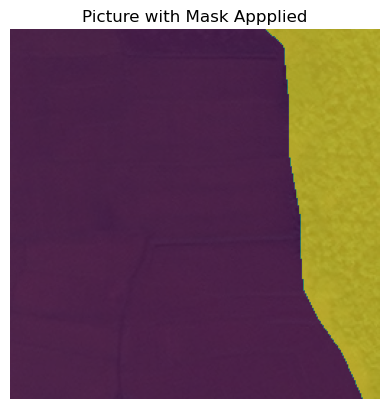

In [5]:
path = image_path + '/' + df['image'][0]
print(path)
img = Image.open(image_path + '/' + df['image'][0])
mask = Image.open(mask_path + '/' + df['mask'][0]).convert('L')
print('Image Size', np.asarray(img).shape)
print('Mask Size', np.asarray(mask).shape)

plt.imshow(img)

plt.imshow(mask,alpha = 0.6)
plt.title('Picture with Mask Appplied')
plt.axis('off')
plt.show()

# /kaggle/input/forest-area-dataset/Forest Segmented/Forest Segmented/masks/10452_mask_08.jpg

In [6]:
class DoubleConv(nn.Module):
  def __init__(self,in_channels,out_channels):
    super(DoubleConv,self).__init__()

    self.conv = nn.Sequential(
        nn.Conv2d(in_channels,out_channels,3,1,1,bias = False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace = True),

        nn.Conv2d(out_channels,out_channels,3,1,1,bias = False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace = True),
    )

  def forward(self,x):
    return self.conv(x)


In [7]:
class UNET(nn.Module):
  def __init__(self,in_channels = 3,out_channels = 1,features = [64,128,256,512]):
    super(UNET,self).__init__()
    self.downs = nn.ModuleList()
    self.ups = nn.ModuleList()
    self.pool = nn.MaxPool2d(kernel_size = 2,stride = 2)

    # Down part of UNET
    for feature in features:
      self.downs.append(DoubleConv(in_channels,feature))
      in_channels = feature

    # Up part of UNET
    for feature in reversed(features):
       self.ups.append(nn.ConvTranspose2d(feature*2,feature,kernel_size = 2,stride = 2))
       self.ups.append(DoubleConv(feature*2,feature))

    self.bottleneck = DoubleConv(features[-1],features[-1]*2)
    self.final_conv = nn.Conv2d(features[0],out_channels,kernel_size = 1)


  def forward(self,x):
    skip_connections = []

    for down in self.downs:
      x = down(x)
      skip_connections.append(x)
      x = self.pool(x)

    x = self.bottleneck(x)

    skip_connections = skip_connections[::-1]

    for idx in range(0,len(self.ups),2):
      x = self.ups[idx](x)

      skip_connection = skip_connections[idx//2]

      if x.shape != skip_connection.shape:
        x = TF.resize(x,size = skip_connection.shape[2:],antialias = True)

      concat_skip = torch.cat((skip_connection,x),dim = 1)
      x = self.ups[idx+1](concat_skip)

    return self.final_conv(x)

def test():
  x = torch.randn((3,3,417,417))
  model = UNET(in_channels=3,out_channels = 1)
  preds = model(x)
  print('------------------------')
  print(x.shape)
  print(preds.shape)
  # assert preds.shape == x.shape

if __name__ == "__main__":
  test()

------------------------
torch.Size([3, 3, 417, 417])
torch.Size([3, 1, 417, 417])


In [8]:
model = UNET()

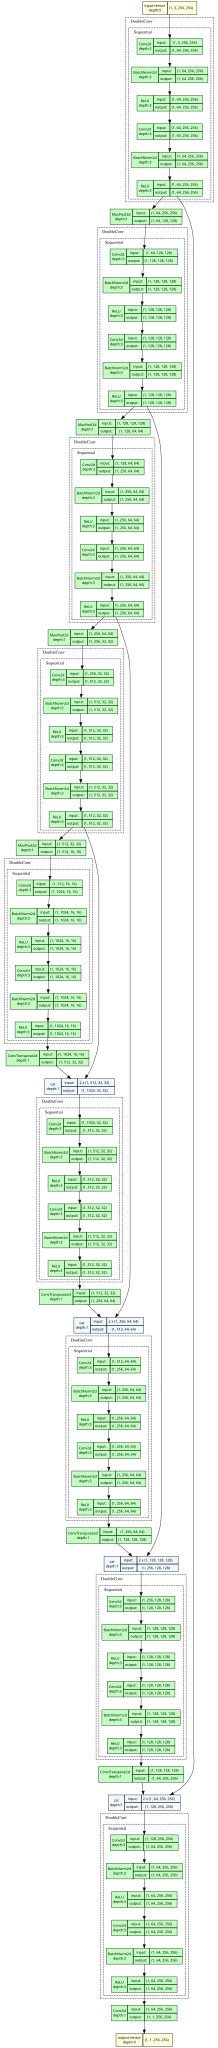

In [9]:
model_graph = draw_graph(model, input_size=(1,3,256,256), expand_nested=True)
model_graph.visual_graph

In [10]:
import os
from PIL import Image
from torch.utils.data import Dataset
import numpy as np
import matplotlib.pyplot as plt
import random

In [11]:
class SlumDataset(Dataset):
  def __init__(self,image_dir,mask_dir,transform = None):
    self.image_dir = image_dir
    self.mask_dir = mask_dir
    self.transform = transform

  def __len__(self):
    return len(self.mask_dir)

  def __getitem__(self,index):
    img_path = os.path.join(image_path,self.image_dir[index])
    msk_path = os.path.join(mask_path,self.mask_dir[index])

    image = np.array(Image.open(img_path).convert('RGB'))
    mask = np.array(Image.open(msk_path).convert('L'), dtype = np.float32)
    
    mask = (mask//248.0)
    image = (image/255.0)


    if self.transform != None:
      augment = self.transform(image = image,mask = mask)
      image = augment['image']
      mask = augment['mask']

      if(image.shape[1:] != mask.shape):
        print("-------------- ---------------------------")
        print("!!!Warning!!!")
        print(image.shape[1:])
        print(mask.shape)

    return image,mask

Just for checking the above code

In [12]:
import torch
import torchvision
from torch.utils.data import DataLoader

In [13]:
def save_checkpoint(state,filename = "my_checkpoint.pth.tar"):
  print("=> Saving checkpoint")
  torch.save(state,filename)

In [14]:
def load_checkpoint(checkpoint,model,optimizer):
  print("=> Loading checkpoint")
  model.load_state_dict(checkpoint["state_dict"])
  optimizer.load_state_dict(checkpoint["optimizer"])

In [15]:
def get_loaders(
    X_train,
    Y_train,
    X_val,
    Y_val,
    batch_size,
    train_transform,
    val_transform,
    train_val,
    num_workers = 2,
    pin_memory = True,
):
    
  train_ds = SlumDataset(
      image_dir = X_train,
      mask_dir = Y_train,
      transform = train_transform
  )

  train_loader = DataLoader(
      train_ds,
      batch_size = batch_size,
      num_workers = num_workers,
      pin_memory = pin_memory,
      shuffle = True,
  )

  val_ds = SlumDataset(
      image_dir = X_val,
      mask_dir = Y_val,
      transform = val_transform
  )

  val_loader = DataLoader(
      val_ds,
      batch_size = batch_size,
      num_workers = num_workers,
      pin_memory = pin_memory,
      shuffle = False,
  )

  return train_loader, val_loader

In [16]:
def dice_coefficient(predicted_mask, ground_truth_mask):
  intersection = np.sum(predicted_mask * ground_truth_mask)
  predicted_area = np.sum(predicted_mask)
  ground_truth_area = np.sum(ground_truth_mask)

  dice = (2.0 * intersection) / (predicted_area + ground_truth_area)
  return dice

def check_accuracy(loss_fn,loader,model,accuracy_vals,dice_scores,iou_scores,precision_scores,recall_scores,f1_val,val_loss,device = "cuda"):
  num_correct = 0
  num_pixels = 0
  dice_s = []
  precision_s = []
  f1_s = []
  iou_s = []
  recall_s = []
  accuracy_s = []
  model.eval()

  with torch.no_grad():
    for x,y in loader:
      x = x.to(device)
      y = y.to(device).unsqueeze(1)
      pred = torch.sigmoid(model(x))

      val_loss += loss_fn(y,pred).item()

      pred = (pred > 0.5).float()
      num_correct += (pred == y).sum()
      num_pixels += torch.numel(pred)
      preds = pred.cpu().numpy()
      yy = y.cpu().numpy()


      for pred_mask, gt_mask in zip(preds, yy):
        # Flatten the binary masks for precision calculation
        pred_mask_flat = pred_mask.flatten()
        gt_mask_flat = gt_mask.flatten()

        # Calculate recall score for the current mask
        recall = recall_score(gt_mask_flat, pred_mask_flat)
        recall_s.append(recall)

        # Calculate precision for the current mask
        precision = precision_score(gt_mask_flat, pred_mask_flat)
        precision_s.append(precision)

        # Calculate F1 score for the current mask
        # F1-score is the harmonic mean of Precision and Recall,
        # F1-score = 2 * (Precision * Recall) / (Precision + Recall)

        f1 = f1_score(gt_mask_flat, pred_mask_flat)
        f1_s.append(f1)

        # Calculate the intersection and union of the binary masks
        intersection = np.sum(pred_mask * gt_mask)
        union = np.sum(np.logical_or(pred_mask, gt_mask))

        # Calculate IoU for the current mask
        iou = intersection / union
        iou_s.append(iou)

        # Calculate Accuarcy for the current mask
        accuracy = np.mean(gt_mask_flat == pred_mask_flat)
        accuracy_s.append(accuracy)

        dice_score = dice_coefficient(pred_mask, gt_mask)
        dice_s.append(dice_score)

  val_loss /= len(loader)
  accu = (num_correct/num_pixels)*100
  print(f"Got {num_correct}/{num_pixels} with accuracy {accu}")

  # Calculate the average precision over the validation dataset
  average_precision = np.mean(precision_s)
  print(f"Average Precision: {average_precision:.4f}")

  #Calculate the average accuracy over the validation dataset
  accuracy_vals.append(np.mean(accuracy_s))
  print(f'Accuracy: {np.mean(accuracy_s)}')

  # Calculate the average Dice score over the validation dataset
  average_dice = np.mean(dice_s)
  print(f"Average Dice Score: {average_dice:.4f}")

  # Calculate the average F1 score over the validation dataset
  average_f1 = np.mean(f1_s)
  print(f"Average F1 Score: {average_f1:.4f}")

  # Calculate the average IoU score over the validation dataset
  average_iou = np.mean(iou_s)
  print(f"Average IoU Score: {average_iou:.4f}")

  # Calculate average metrics for the epoch
  iou_scores.append(average_iou)
  precision_scores.append(average_precision)
  recall_scores.append(np.mean(recall_s))
  f1_val.append(average_f1)
  dice_scores.append(average_dice)

  model.train()

In [17]:
def save_predictions_as_imgs(loader,model,folder="saved_images/",device = "cuda"):
  model.eval()
  for idx, (x,y) in enumerate(loader):
    x = x.to(device = device)

    with torch.no_grad():
      preds = torch.sigmoid(model(x))
      preds = (preds > 0.5).float()
      # preds = (preds > 0.5).astype(torch.int)

    torchvision.utils.save_image(preds,f"{folder}/pred_{idx}.jpg")
    torchvision.utils.save_image(y.unsqueeze(1),f"{folder}/{idx}.jpg")

  model.train()


def my_plot(epochs, loss):
  plt.xlabel("losses")
  plt.ylabel("Num of epochs")
  plt.plot(epochs, loss)

Implement Focal Loss using predefined BCEWithLogitsLoss

In [18]:
# Custom Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = nn.BCEWithLogitsLoss()(inputs, targets)
        pt = torch.exp(-BCE_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
        return focal_loss

All the hyperparameters and dataset path

In [19]:
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
from numpy import random

import numpy as np
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt

# Hyperparameters
LEARNING_RATE = 1e-4
device = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BATCH_SIZE = 32
NUM_EPOCHS = 12
NUM_WORKERS = 2
train_val = 0.9

IMAGE_HEIGHT = 256
IMAGE_WIDTH = 256

PIN_MEMORY = True
LOAD_MODEL = True

In [20]:
def train_fn(epoch,num_epochs,loader,model,optimizer,loss_fn,scaler,iou_train,precision_train,recall_train,f1_train,loss_train,accuracy_train):
  total_loss = 0.0
  total_iou = 0.0
  total_precision = 0.0
  total_recall = 0.0
  total_f1 = 0.0
  accuracy_s = []
  total_accuracy = 0.0

  length = len(loader);
  loop = tqdm(loader)

  for batch_idx, (data,targets) in enumerate(loop):
    data = data.to(device = device)
    targets = targets.float().unsqueeze(1).to(device = device)
    targ = targets

    # forward
    with torch.cuda.amp.autocast():
      predictions = torch.sigmoid(model(data))

      loss = loss_fn(predictions,targets)
      total_loss += loss.item()

      # convert model outputs to binary mask using sigmoid and threshold
      predicted_masks = predictions
      predicted_masks = (predicted_masks > 0.5).float()

      preds = predicted_masks.cpu().numpy()
      yy = targ.cpu().numpy()

      # Calculate the intersection and union of the binary masks
      intersection = np.sum(preds * yy)
      union = np.sum(np.logical_or(preds, yy))
      iou = intersection / union

      precision = precision_score(yy.flatten(), preds.flatten())
      recall = recall_score(yy.flatten(), preds.flatten())
      f1 = f1_score(yy.flatten(), preds.flatten())
    
      for pred_mask,gt_mask in zip(preds,yy):
        x = np.mean(gt_mask.flatten() == pred_mask.flatten())
        accuracy_s.append(x)

      total_iou += iou
      total_precision += precision
      total_recall += recall
      total_f1 += f1
#       total_accuracy += accuracy

    # backward
    optimizer.zero_grad()
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    # update tqdm loop
    loop.set_postfix(loss = loss.item())

  average_loss = total_loss / length
  average_iou = total_iou / length
  average_precision = total_precision / length
  average_recall = total_recall / length
  average_f1 = total_f1 / length
  # average_accuracy = accuracy /length

  # Append metrics and losses to lists for plotting
  loss_train.append(average_loss)
  iou_train.append(average_iou)
  precision_train.append(average_precision)
  recall_train.append(average_recall)
  f1_train.append(average_f1)
  accuracy_train.append(np.mean(accuracy_s))

  print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Loss: {average_loss:.4f}, "
          f"IoU: {average_iou:.4f}, "
          f"Precision: {average_precision:.4f}, "
          f"Recall: {average_recall:.4f}, "
          f"F1: {average_f1:.4f},"
          f"Accuracy: {np.mean(accuracy_s):4f}"
  )

/opt/conda/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:139: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "
100%|██████████| 144/144 [08:26<00:00,  3.52s/it, loss=0.103]


Epoch [1/12], Loss: 0.1163, IoU: 0.6586, Precision: 0.8329, Recall: 0.7590, F1: 0.7919,Accuracy: 0.758950
=> Saving checkpoint


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defin

Got 26180149/33488896 with accuracy 78.17560577392578
Average Precision: 0.7795
Accuracy: 0.7817561080544428
Average Dice Score: 0.6944
Average F1 Score: 0.6944
Average IoU Score: 0.6115


100%|██████████| 144/144 [08:30<00:00,  3.55s/it, loss=0.0903]


...

Got 26546749/33488896 with accuracy 79.27029418945312
Average Precision: 0.8021
Accuracy: 0.7927030201294184
Average Dice Score: 0.6858
Average F1 Score: 0.6858
Average IoU Score: 0.6003


100%|██████████| 144/144 [07:35<00:00,  3.16s/it, loss=0.0996]


Epoch [12/12], Loss: 0.1014, IoU: 0.7227, Precision: 0.8644, Recall: 0.8165, F1: 0.8383,Accuracy: 0.808211
=> Saving checkpoint


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defin

Got 26832438/33488896 with accuracy 80.1233901977539
Average Precision: 0.8029
Accuracy: 0.8012338776411142
Average Dice Score: 0.7005
Average F1 Score: 0.7005
Average IoU Score: 0.6166
Training finished
loss_train : [0.11630517399559419, 0.10856595262885094, 0.10554333952152067, 0.10338470174206628, 0.10249164105496472, 0.10201540496200323, 0.10178953062535988, 0.10113183947073089, 0.10110837252189715, 0.1005321822853552, 0.10106564990969168, 0.10135573143553403]
iou_train : [0.6585623040919505, 0.6852283446340249, 0.692135908435123, 0.711306449653886, 0.7154600073510174, 0.7200931399925574, 0.7166527640060579, 0.7251876676401082, 0.7248763237438011, 0.726561811373324, 0.7233691994608346, 0.7227035253473302]
precision_train : [0.8329196743857685, 0.8496813951179822, 0.858539175934935, 0.8586077297464528, 0.862279359264727, 0.8634020342418404, 0.8656639252658495, 0.8644866501312698, 0.8649521621376662, 0.8683158338960703, 0.8653977756896857, 0.8643540177562743]
recall_train : [0.758956

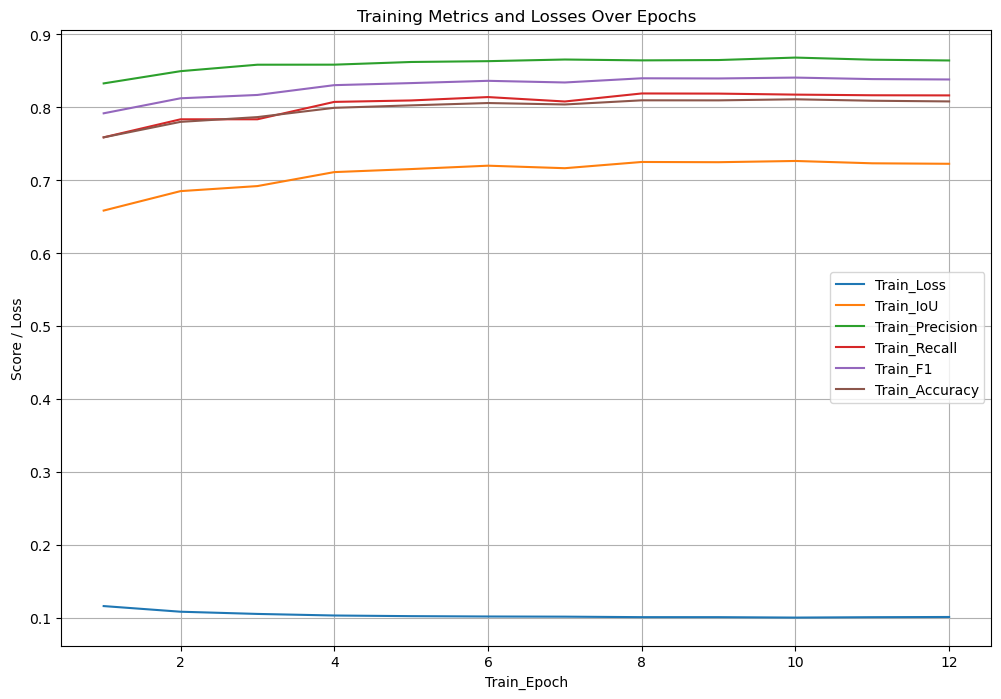

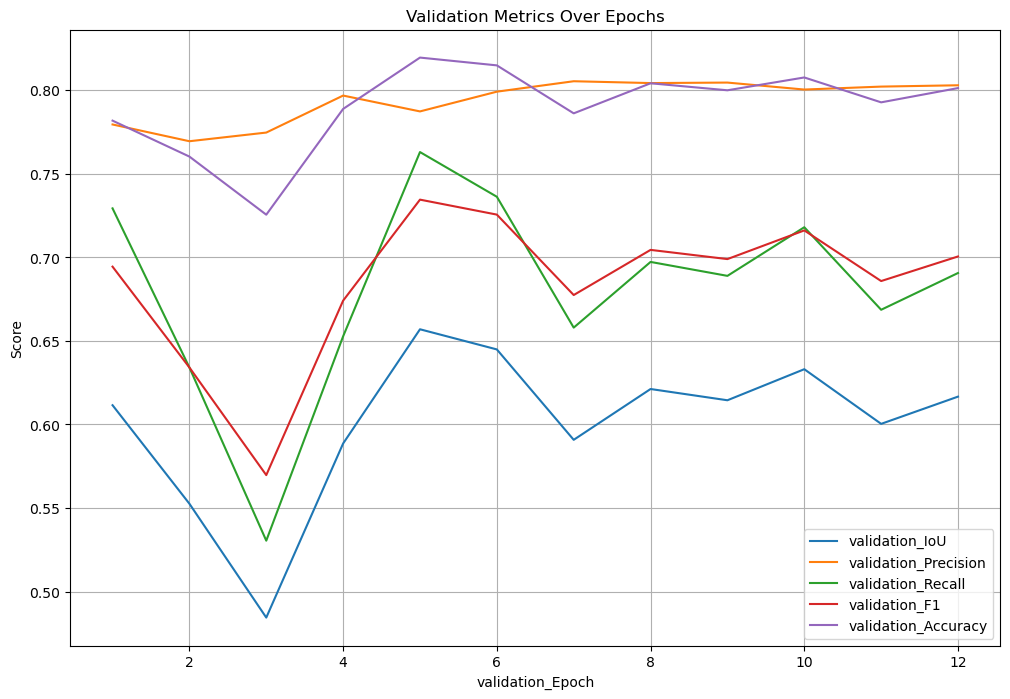

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 256, 256]           1,728
       BatchNorm2d-2         [-1, 64, 256, 256]             128
              ReLU-3         [-1, 64, 256, 256]               0
            Conv2d-4         [-1, 64, 256, 256]          36,864
       BatchNorm2d-5         [-1, 64, 256, 256]             128
              ReLU-6         [-1, 64, 256, 256]               0
        DoubleConv-7         [-1, 64, 256, 256]               0
         MaxPool2d-8         [-1, 64, 128, 128]               0
            Conv2d-9        [-1, 128, 128, 128]          73,728
      BatchNorm2d-10        [-1, 128, 128, 128]             256
             ReLU-11        [-1, 128, 128, 128]               0
           Conv2d-12        [-1, 128, 128, 128]         147,456
      BatchNorm2d-13        [-1, 128, 128, 128]             256
             ReLU-14        [-1, 128, 1

In [21]:
def main():
  train_transform = A.Compose(
    [
      A.Resize(height = IMAGE_HEIGHT,width = IMAGE_WIDTH),
      A.RandomCrop(height = IMAGE_HEIGHT,width=IMAGE_WIDTH),
      A.Rotate(limit = 35,p=1.0),
      A.HorizontalFlip(p=0.5),
      A.VerticalFlip(p=0.1),
      A.Normalize(
          mean=[0.0,0.0,0.0],
          std = [1.0,1.0,1.0],
          max_pixel_value = 1.0
      ),
      ToTensorV2(),
    ], is_check_shapes=False
  )

  val_transform = A.Compose(
    [
     A.Resize(height = IMAGE_HEIGHT,width = IMAGE_WIDTH),
     A.RandomCrop(height = IMAGE_HEIGHT,width=IMAGE_WIDTH),
     A.Normalize(
      mean=[0.0,0.0,0.0],
      std = [1.0,1.0,1.0],
      max_pixel_value = 1.0
    ),
    ToTensorV2(),
  ], is_check_shapes=False
  )

  train_loader,val_loader = get_loaders(
      X_train,
      Y_train,
      X_val,
      Y_val,
      BATCH_SIZE,
      train_transform,
      val_transform,
      train_val,
      NUM_WORKERS,
      PIN_MEMORY,
  )

  model = UNET().to("cuda" if torch.cuda.is_available() else "cpu")
  loss_fn = FocalLoss()

  optimizer = optim.Adam(model.parameters(),lr = LEARNING_RATE)
  scheduler = StepLR(optimizer, step_size=4, gamma=0.1)

  # if LOAD_MODEL:
    # load_checkpoint(torch.load("my_checkpoint.pth.tar"),model)
    # load_checkpoint(torch.load("my_checkpoint.pth.tar"),model,optimizer=optimizer)

  scaler = torch.cuda.amp.GradScaler()

  # Initialize lists to store metric values for each epoch for validation dataset
  iou_scores = []
  precision_scores = []
  recall_scores = []
  f1_val = []
  dice_scores = []
  accuracy_vals = []

  # Initialize lists to store metric values for each epoch for training dataset
  iou_train = []
  precision_train = []
  recall_train = []
  f1_train = []
  loss_train = []
  accuracy_train = []

  # Number of patience for early stopping
  # patience = 10
  # best_val_loss = float('inf')
  # best_val_loss = torch.tensor(float('inf'))
  # counter = 0

  for epoch in range(NUM_EPOCHS):
    scheduler.step()
    train_fn(epoch,NUM_EPOCHS,train_loader,model,optimizer,loss_fn,scaler,iou_train,precision_train,recall_train,f1_train,loss_train,accuracy_train)

    # save model
    checkpoint = {
        "state_dict": model.state_dict(),
        "optimizer": optimizer.state_dict(),
    }
    save_checkpoint(checkpoint)

    # check_accuracy
    val_loss = 0.0
    check_accuracy(loss_fn,val_loader,model,accuracy_vals,dice_scores,iou_scores,precision_scores,recall_scores,f1_val,val_loss,device = DEVICE)

    #  if val_loss < best_val_loss:
    #         best_val_loss = val_loss
    #         counter = 0
    #  else:
    #         counter += 1
    #         if counter >= patience:
    #             print("Early stopping triggered.")
    #             break

    # print some examples to the folder
    save_predictions_as_imgs(
        val_loader,model,folder=saved_folder,device = DEVICE
    )
  print("Training finished")

  print(f'loss_train : {loss_train}')
  print(f'iou_train : {iou_train}')
  print(f'precision_train : {precision_train}')
  print(f'recall_train : {recall_train}')
  print(f'f1_train : {f1_train}')
  
  print(f'Validation result')
  print(f'f1_val: {f1_val}')
  print(f'dice_scores : {dice_scores}')
  print(f'iou_scores : {iou_scores}')
  print(f'precision_scores : {precision_scores}')
  print(f'recall_scores : {recall_scores}')
  print(f'Accuracy_scores : {accuracy_vals}')

  # Plot metrics and losses
  # Plot for Training dataset
  epochs = np.arange(1, NUM_EPOCHS + 1)
  plt.figure(figsize=(12, 8))

  plt.plot(epochs, loss_train, label='Train_Loss')
  plt.plot(epochs, iou_train, label='Train_IoU')
  plt.plot(epochs, precision_train, label='Train_Precision')
  plt.plot(epochs, recall_train, label='Train_Recall')
  plt.plot(epochs, f1_train, label='Train_F1')
  plt.plot(epochs, accuracy_train, label='Train_Accuracy')

  plt.xlabel('Train_Epoch')
  plt.ylabel('Score / Loss')
  plt.title('Training Metrics and Losses Over Epochs')
  plt.legend()
  plt.grid()

  plt.show()

  # PLot validation metrics
  plt.figure(figsize=(12, 8))

  plt.plot(epochs, iou_scores, label='validation_IoU')
  plt.plot(epochs, precision_scores, label='validation_Precision')
  plt.plot(epochs, recall_scores, label='validation_Recall')
  plt.plot(epochs, dice_scores, label='validation_F1')
  plt.plot(epochs,accuracy_vals,label = "validation_Accuracy")

  plt.xlabel('validation_Epoch')
  plt.ylabel('Score')
  plt.title('Validation Metrics Over Epochs')
  plt.legend()
  plt.grid()

  plt.show()

  summary(model,input_size = (3,IMAGE_HEIGHT,IMAGE_WIDTH))

if __name__ == "__main__":
  main()